In [80]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import sys
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
sys.path.append(r"C:\Users\Tao Yu\d2lzh_pytorch")
import d2lzh_pytorch as d2l

In [81]:
print(torch.__version__)
print(torchvision.__version__)

2.4.0
0.19.0


In [82]:
mnist_train = torchvision.datasets.MNIST(root='~/Datasets/MNIST',train=True,download=True,transform=transforms.ToTensor())
mnist_test = torchvision.datasets.MNIST(root='~/Datasets/MNIST',train=False,download=True,transform=transforms.ToTensor())

In [83]:
 print(type(mnist_train))
 print(len(mnist_train), len(mnist_test))

<class 'torchvision.datasets.mnist.MNIST'>
60000 10000


In [84]:
 feature, label = mnist_train[0]
 print(feature.shape, feature.dtype)
 print(label)
 print(mnist_train[0][0].size())
 print(len(mnist_train[0]),len(mnist_train[0][0]),len(mnist_train[0][0][0]))
 print(mnist_train[0])
 # Channel × Height × Width
 # 灰度图像，通道数为1，高28，宽28
 # 10个类别，0~9

torch.Size([1, 28, 28]) torch.float32
5
torch.Size([1, 28, 28])
2 1 28
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0

In [85]:
 # 本函数将数值标签转换成相应的文本标签
def get_mnist_labels(labels):
     text_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
     return [text_labels[int(i)] for i in labels]

In [86]:
 # 本函数可以在一行里画出多张图像和对应标签
def show_mnist(images, labels):
    d2l.use_svg_display()
 # 这里的_表示我们忽略（不使用）的变量
    _, figs = plt.subplots(1, len(images), figsize=(12, 12))
 # figsize使每个像素点大小变小
    for f, img, lbl in zip(figs, images, labels):
        f.imshow(img.view((28, 28)).numpy())
        f.set_title(lbl)
        f.axes.get_xaxis().set_visible(False)
        f.axes.get_yaxis().set_visible(False)
 # 隐藏坐标轴
    plt.show()

In [87]:
 # zip()函数将对应元素打包成一个元组
x = [1,2,3,4,5]
y = ['a','b','c','d','e']
xy = zip(x,y)
print(xy)
for x in xy:
    print(x)
    print(x[0])

(1, 'a')
1
(2, 'b')
2
(3, 'c')
3
(4, 'd')
4
(5, 'e')
5


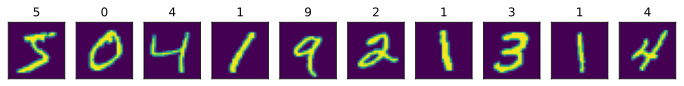

In [88]:
 # append():在数组后面加上相应的元素
# 查看训练集中前10个样本的图像内容和标签
X, y = [], []
for i in range(10):
    X.append(mnist_train[i][0])
    y.append(mnist_train[i][1])
show_mnist(X, get_mnist_labels(y))

In [89]:
batch_size = 256
if sys.platform.startswith('win'):
    num_workers = 0  # 在Windows上设为0以避免多进程问题
else:
    num_workers = 4  # 在非Windows系统上可以使用多个工作进程加速数据加载
train_iter = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_iter = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [90]:
start = time.time()
for X, y in train_iter:
    continue
print('%.2f sec' % (time.time() - start))

2.52 sec


In [91]:
def load_data_mnist(batch_size, resize=None):
    # 数据预处理
    transform = [transforms.ToTensor()]
    if resize:  # 如果指定了调整大小
        transform.insert(0, transforms.Resize(resize))
    transform = transforms.Compose(transform)
    # 创建 DataLoader
    train_iter = DataLoader(mnist_train, batch_size, shuffle=True)
    test_iter = DataLoader(mnist_test, batch_size, shuffle=False)

    return train_iter, test_iter

In [92]:
 # 设置批量大小为256
 # d2l中utils.py 第88行和第249行
# 获取Fashion-MNIST数据集逻辑封装在函数中
batch_size = 256
train_iter, test_iter = load_data_mnist(batch_size)

In [93]:
 # 层的输入和输出
num_inputs = 784 # 28×28
num_outputs = 10
W = torch.tensor(np.random.normal(0, 0.01, (num_inputs, num_outputs)), dtype=torch.float)
b = torch.zeros(num_outputs, dtype=torch.float)

In [94]:
# 设置requires_grad参数为True
print(W.requires_grad_(requires_grad=True))
print(W.size())
print(b.requires_grad_(requires_grad=True))
print(b.size())

tensor([[-0.0012, -0.0133, -0.0116,  ...,  0.0033, -0.0040, -0.0062],
        [-0.0045, -0.0011, -0.0005,  ..., -0.0124, -0.0085,  0.0125],
        [ 0.0054,  0.0085,  0.0013,  ..., -0.0142,  0.0106, -0.0057],
        ...,
        [-0.0038, -0.0073,  0.0021,  ..., -0.0038, -0.0012,  0.0062],
        [-0.0108,  0.0017, -0.0074,  ..., -0.0017,  0.0026, -0.0108],
        [-0.0193,  0.0010, -0.0058,  ..., -0.0003, -0.0035,  0.0003]],
       requires_grad=True)
torch.Size([784, 10])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True)
torch.Size([10])


In [95]:
 # 对多维Tensor的某一维度进行操作
# dim=0对同一列进行操作，dim=1对同一行进行操作
# keepdim=True表示保留原本维度
X = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(X.sum(dim=0, keepdim=True))
print(X.sum(dim=1, keepdim=True))
print(X)
print(X.sum(dim=1, keepdim=False))
print(X)

tensor([[5, 7, 9]])
tensor([[ 6],
        [15]])
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([ 6, 15])
tensor([[1, 2, 3],
        [4, 5, 6]])


In [96]:
def softmax(X):
    X_exp = X.exp()
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition  # 这里应用了广播机制

In [97]:
# 试验softmax函数
X = torch.rand(2,5)
print(X)
X_prob = softmax(X)
print(X_prob,X_prob.sum(dim=1))

tensor([[0.8103, 0.2714, 0.9357, 0.8691, 0.6899],
        [0.7556, 0.2193, 0.2926, 0.0051, 0.7045]])
tensor([[0.2144, 0.1251, 0.2431, 0.2274, 0.1901],
        [0.2750, 0.1608, 0.1731, 0.1298, 0.2613]]) tensor([1.0000, 1.0000])


In [98]:
 # W和b已经被初始化好了
# 通过view函数将每张原始图像改为长度为num_inputs的向量
def net(X):
    return softmax(torch.mm(X.view((-1, num_inputs)), W) + b)

In [99]:
 # gather函数的用法
# y_hat 是对2个样本对3个类别的预测概率，y 是两个样本的真实标签
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y = torch.LongTensor([0, 2])
print(y.view(-1, 1))
print(y_hat.gather(1, y.view(-1, 1)))

tensor([[0],
        [2]])
tensor([[0.1000],
        [0.5000]])


In [100]:
 #交叉熵损失函数
def cross_entropy(y_hat, y):
    return - torch.log(y_hat.gather(1, y.view(-1, 1)))

In [101]:
 # 准确率accuracy函数
# y_hat.argmax(dim=1)返回矩阵y_hat每行中最大元素的索引
# .float()把ByteTensor类型的Tensor转换成浮点数0或1
 # .mean()求平均
# .item()将一个元素的tensor转换为元素本身
def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

In [102]:
print(accuracy(y_hat, y))

0.5


In [103]:
 # 评价模型net在数据集data_iter上的准确率
def evaluate_accuracy(data_iter, net):
    acc_sum, n = 0.0, 0
    for X, y in data_iter:
        acc_sum += (net(X).argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]
    return acc_sum / n

In [104]:
print(evaluate_accuracy(test_iter, net))

0.0914


In [105]:
num_epochs, lr = 5, 0.1
loss = cross_entropy
def train_ch3(net, train_iter, test_iter, loss, num_epochs, batch_size,
              params=None, lr=None, optimizer=None):
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
        for X, y in train_iter:
            y_hat = net(X)
            l = loss(y_hat, y).sum()
            # 梯度清零
            if optimizer is not None:
                optimizer.zero_grad()
            elif params is not None and params[0].grad is not None:
                for param in params:
                    param.grad.data.zero_()
            l.backward()
            if optimizer is None:
                d2l.sgd(params, lr, batch_size)
            else:
                optimizer.step()  # “softmax回归的简洁实现”一节将用到
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
            n += y.shape[0]
        test_acc = evaluate_accuracy(test_iter, net)
        print('epoch %d, loss %.4f, train acc %.3f, test acc %.3f'
              % (epoch + 1, train_l_sum / n, train_acc_sum / n, test_acc))
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, batch_size, [W, b], lr)

epoch 1, loss 0.7119, train acc 0.843, test acc 0.888
epoch 2, loss 0.4292, train acc 0.887, test acc 0.900
epoch 3, loss 0.3836, train acc 0.896, test acc 0.907
epoch 4, loss 0.3605, train acc 0.901, test acc 0.908
epoch 5, loss 0.3458, train acc 0.904, test acc 0.912


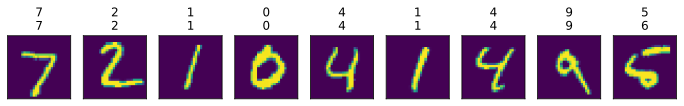

In [106]:
 # 通过iter()获取这些可迭代对象的迭代器，对获取到的迭代器使用next()获取下一条数据
X, y = iter(test_iter).__next__()
true_labels = get_mnist_labels(y.numpy())
pred_labels = get_mnist_labels(net(X).argmax(dim=1).numpy())
titles = [true + '\n' + pred for true, pred in zip(true_labels, pred_labels)]
show_mnist(X[0:9], titles[0:9])

In [107]:
a = [1,2,3,4,5]
a_iter = iter(a)
print(next(a_iter))
print(next(a_iter))
print(next(a_iter))
 # 注意，当我们已经迭代完最后⼀个数据之后，再次调⽤next()函数会抛出 StopIteration的异常
# 不用执行next()函数了

1
2
3
